In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carrega o dataset de falas
quotes = pd.read_csv('../data/raw/friends_quotes.csv')

# Quantas falas cada personagem tem no total?
falas_por_personagem = quotes['author'].value_counts()
print(falas_por_personagem.head(20))

author
Rachel        8318
Ross          8088
Monica        7516
Chandler      7488
Joey          7373
Phoebe        6699
ROSS           832
CHANDLER       691
MONICA         658
JOEY           642
RACHEL         638
PHOEBE         561
Mike           318
All            287
Janice         206
Charlie        190
Emily          160
Mr. Geller     153
Carol          150
Tag            146
Name: count, dtype: int64


In [2]:
# Os 6 personagens principais
principais = ['Rachel', 'Monica', 'Phoebe', 'Ross', 'Chandler', 'Joey']

# Filtra só as falas deles
quotes_principais = quotes[quotes['author'].isin(principais)]

print(f"Total de falas dos 6 principais: {len(quotes_principais)}")
print(f"Total de falas no dataset: {len(quotes)}")

Total de falas dos 6 principais: 45482
Total de falas no dataset: 60291


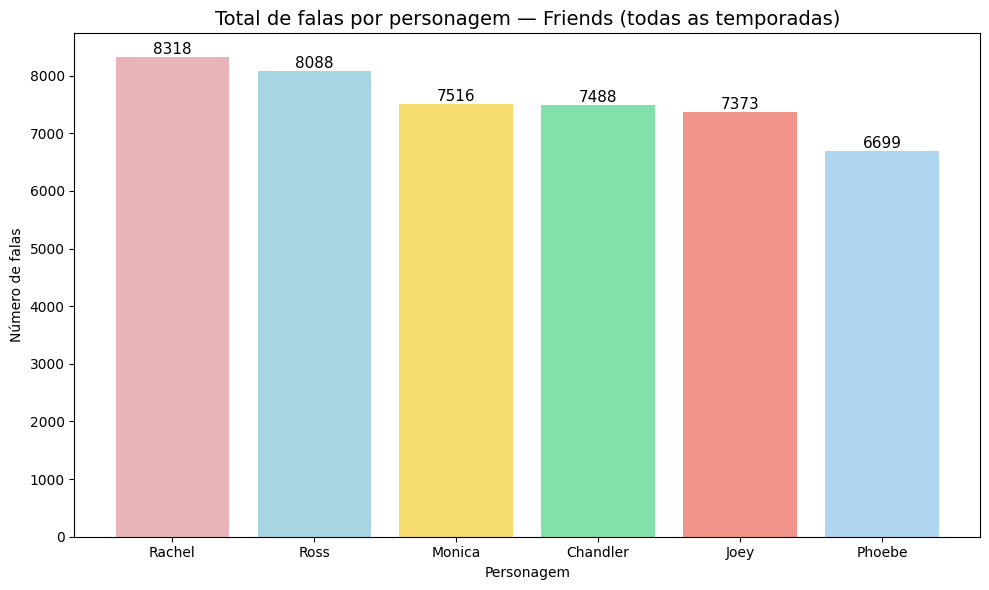

In [ ]:
# Conta falas por personagem
contagem = quotes_principais['author'].value_counts()

# Configura o gráfico
plt.figure(figsize=(10, 6))
cores = ['#E8B4B8', '#A8D5E2', '#F7DC6F', '#82E0AA', '#F1948A', '#AED6F1']

plt.bar(contagem.index, contagem.values, color=cores)
plt.title('Total de falas por personagem — Friends (todas as temporadas)', fontsize=14)
plt.xlabel('Personagem')
plt.ylabel('Número de falas')

# Adiciona o número em cima de cada barra
for i, v in enumerate(contagem.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('../outputs/falas_por_personagem.png', dpi=150)
plt.show()

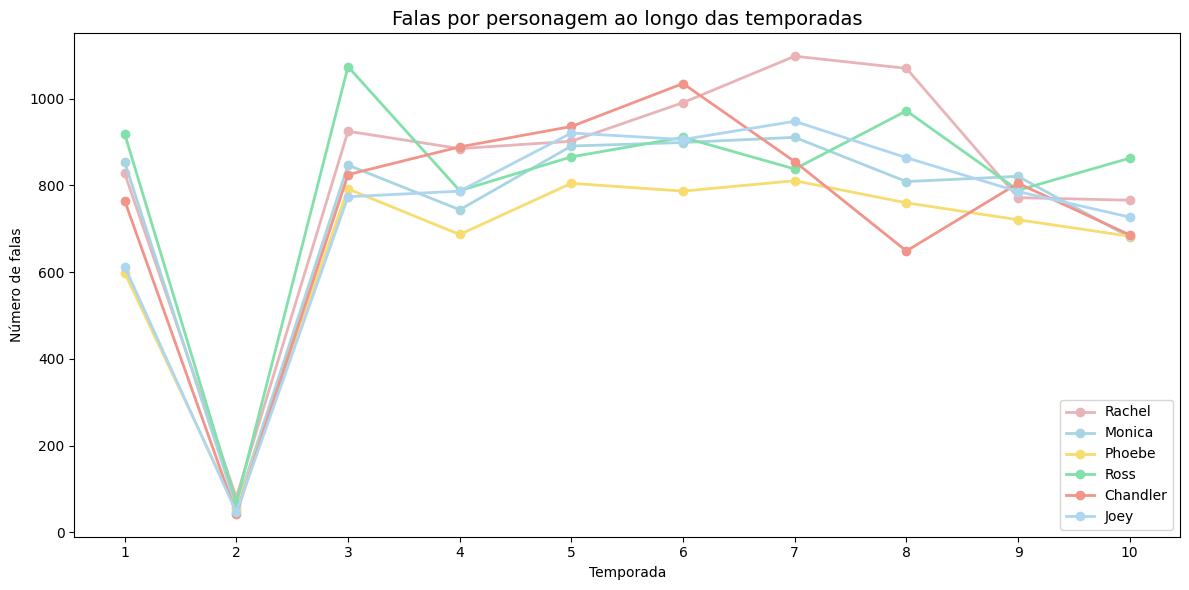

In [10]:
# Agrupa por temporada e personagem
por_temporada = quotes_principais.groupby(['season', 'author'])['quote'].count().reset_index()
por_temporada.columns = ['Temporada', 'Personagem', 'Falas']

# Gráfico de linhas — evolução ao longo das temporadas
plt.figure(figsize=(12, 6))

cores_personagens = {
    'Rachel':   '#E8B4B8',
    'Monica':   '#A8D5E2',
    'Phoebe':   '#F7DC6F',
    'Ross':     '#82E0AA',
    'Chandler': '#F1948A',
    'Joey':     '#AED6F1'
}

for personagem in principais:
    dados = por_temporada[por_temporada['Personagem'] == personagem]
    plt.plot(dados['Temporada'], dados['Falas'],
             marker='o', label=personagem,
             color=cores_personagens[personagem], linewidth=2)

plt.title('Falas por personagem ao longo das temporadas', fontsize=14)
plt.xlabel('Temporada')
plt.ylabel('Número de falas')
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/falas_por_temporada.png', dpi=150)
plt.show()

In [5]:
# Quantas falas tem em cada temporada?
falas_por_temporada = quotes.groupby('season')['quote'].count().reset_index()
falas_por_temporada.columns = ['temporada', 'total_falas']
print(falas_por_temporada)

   temporada  total_falas
0        1.0         5979
1        2.0         5549
2        3.0         6502
3        4.0         5768
4        5.0         6150
5        6.0         6440
6        7.0         6461
7        8.0         6107
8        9.0         6040
9       10.0         5295


In [9]:
# Vamos ver como a temporada está registrada na coluna season
print("Valores únicos na coluna season:")
print(quotes['season'].unique())

print("\nTipo de dado da coluna season:")
print(quotes['season'].dtype)

# Verifica se tem valores nulos
print("\nValores nulos por coluna:")
print(quotes[['author', 'season', 'episode_number']].isnull().sum())

Valores únicos na coluna season:
[ 1  2  3  4  5  6  7  8  9 10]

Tipo de dado da coluna season:
int64

Valores nulos por coluna:
author            0
season            0
episode_number    0
dtype: int64


In [7]:
# Corrige o tipo de dado da coluna season de float para int
quotes['season'] = quotes['season'].astype(int)
quotes['episode_number'] = quotes['episode_number'].astype(int)

# Confirma a correção
print(quotes['season'].dtype)
print(quotes['season'].unique())

int64
[ 1  2  3  4  5  6  7  8  9 10]


In [11]:
# Quantas falas cada personagem principal tem na temporada 2?
t2 = quotes_principais[quotes_principais['season'] == 2]
print("Falas na temporada 2 por personagem:")
print(t2['author'].value_counts())

print("\nFalas na temporada 3 por personagem (para comparar):")
t3 = quotes_principais[quotes_principais['season'] == 3]
print(t3['author'].value_counts())

Falas na temporada 2 por personagem:
author
Rachel      81
Ross        68
Monica      59
Phoebe      54
Joey        47
Chandler    43
Name: count, dtype: int64

Falas na temporada 3 por personagem (para comparar):
author
Ross        1074
Rachel       925
Monica       847
Chandler     825
Phoebe       792
Joey         774
Name: count, dtype: int64


In [12]:
# Remove temporada 2 por dados incompletos no dataset original
quotes_sem_t2 = quotes_principais[quotes_principais['season'] != 2]

# Agrupa por temporada e personagem
por_temporada = quotes_sem_t2.groupby(['season', 'author'])['quote'].count().reset_index()
por_temporada.columns = ['Temporada', 'Personagem', 'Falas']

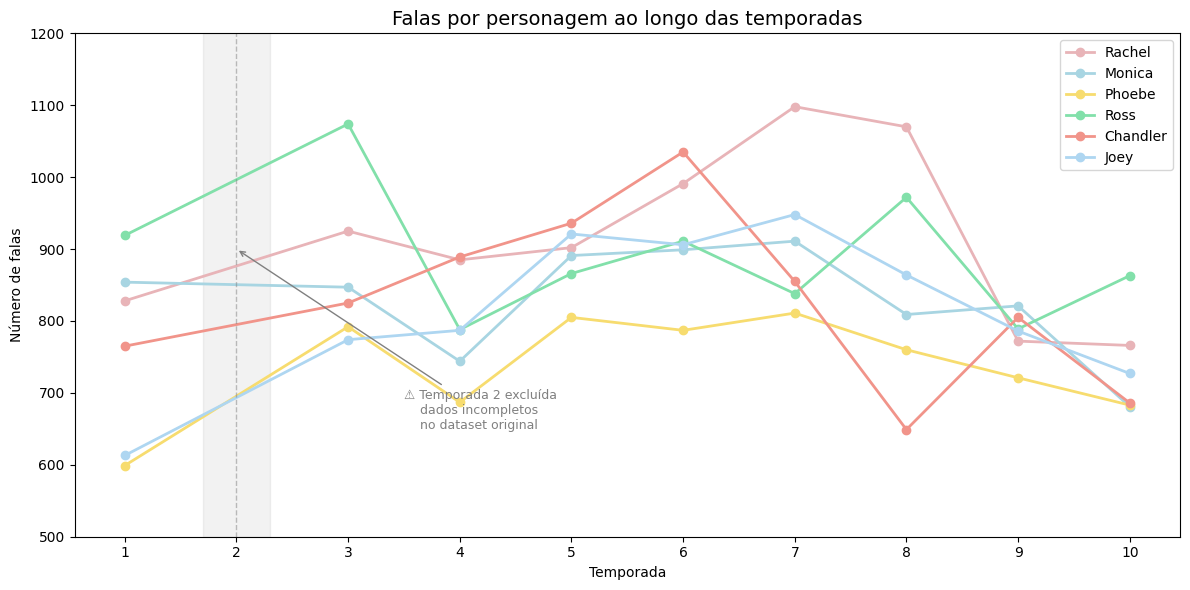

In [14]:
plt.figure(figsize=(12, 6))

for personagem in principais:
    dados = por_temporada[por_temporada['Personagem'] == personagem]
    plt.plot(dados['Temporada'], dados['Falas'],
             marker='o', label=personagem,
             color=cores_personagens[personagem], linewidth=2)

# Faixa cinza na temporada 2
plt.axvspan(1.7, 2.3, color='gray', alpha=0.1)

# Linha tracejada vertical para indicar o gap
plt.axvline(x=2, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Anotação reposicionada para não cortar
plt.annotate(
    '⚠ Temporada 2 excluída\n    dados incompletos\n    no dataset original',
    xy=(2, 900),
    xytext=(3.5, 650),
    fontsize=9,
    color='gray',
    arrowprops=dict(arrowstyle='->', color='gray')
)

plt.title('Falas por personagem ao longo das temporadas', fontsize=14)
plt.xlabel('Temporada')
plt.ylabel('Número de falas')
plt.xticks(range(1, 11))
plt.ylim(500, 1200)  # garante espaço suficiente para a anotação
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../outputs/falas_por_temporada.png', dpi=150)
plt.show()